# Comparing landscapes inferred from different data sources

`gpmap-tools` enables inference of genotype-phenotype maps from both high throughput experiments and observations of natural sequences. Both sources of data have advantages and disadvanges, and capture different aspects of natural sequence-function maps. Comparison of landscapes inferred from different data for the same functional element is therefore essential to understand which features are shared and which are different. 

In this section, we do this comparison for the Shine-Dalgarno (SD) sequence using the visualization technique implemented in `gpmap-tools` to compare, not only the quantitative estimates for each sequences, but the geometry and qualitative features induced by them.

In [1]:
# Import required libraries
import gpmap.plot.mpl as mplot
import gpmap.plot.ds as dplot

from gpmap.space import SequenceSpace
from gpmap.randwalk import WMWalk
from gpmap.datasets import DataSet

### Loading datasets

These landscapes were inferred as shown in the "Inference" section. Here we use the built-in datasets to directly visualize them



In [2]:
datasets = {'Natural sequences': (DataSet('shine_dalgarno'), {'Ns': 1}, 'logQ'),
            'Experimental data': (DataSet('dmsc'), {'mean_function': 2.0}, 'f')}

### Computing coordinates of the visualizations

In [3]:
visualizations = {}
for label, (dataset, kwargs, f) in datasets.items():
    space = SequenceSpace(X=dataset.landscape.index.values,
                          y=dataset.landscape[f].values)
    rw = WMWalk(space)
    rw.calc_visualization(**kwargs)
    visualizations[label] = {'nodes': rw.nodes_df,
                             'edges': space.get_edges_df()}


### Visualizing the inferred landscapes

Given the large number of edges to render, we will use the `datashader` backend to first render the edges.

In [4]:
dsg1 = dplot.plot_edges(visualizations['Natural sequences']['nodes'],
                        edges_df=visualizations['Natural sequences']['edges'],
                        resolution=1200)
dsg2 = dplot.plot_edges(visualizations['Experimental data']['nodes'],
                        edges_df=visualizations['Experimental data']['edges'],
                        resolution=1200)
fig = dplot.dsg_to_fig(dsg1 + dsg2)
fig.set_size_inches((10, 5))

Now, we will plot the genotypes colored by their phenotypes using `matplotlib`. To show that the geometry of the inferred landscapes is essentially the same, where the fitness peaks correspond to different location of the cannonical SD motif relative to the start codon, we will highlight a sequence from each peak in both visualizations.

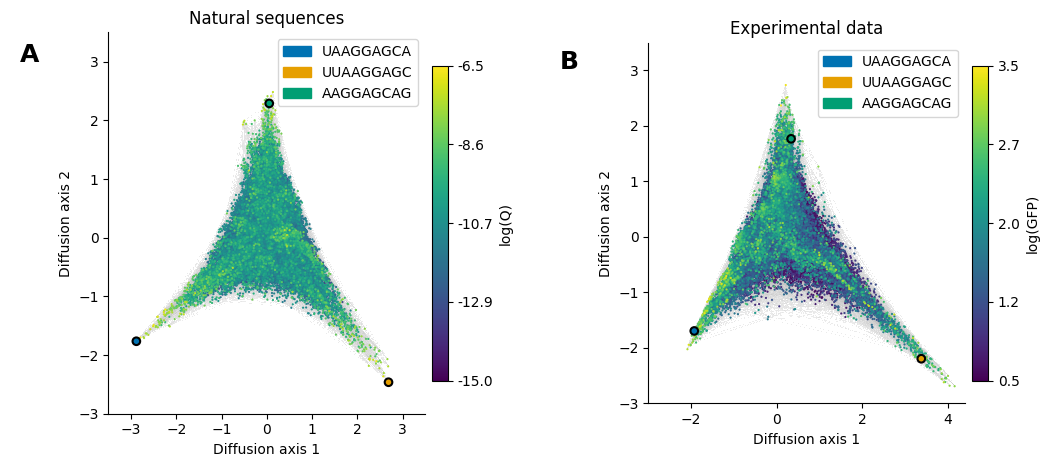

In [5]:
kwargs = {'Experimental data': {'cbar_label': 'log(GFP)', 'vmin': 0.5},
          'Natural sequences': {'cbar_label': 'log(Q)', 'vmin': -15.}}
mpl_kwargs = {'Experimental data': {'title': 'Experimental data', 'xlim': (-3, 4.4), 'ylim': (-3, 3.5)},
              'Natural sequences': {'title': 'Natural sequences', 'xlim': (-3.5, 3.5), 'ylim': (-3, 3.5)}}
seqs = ['UAAGGAGCA', 'UUAAGGAGC', 'AAGGAGCAG']
palette = dict(zip(seqs, ['#0072B2', '#E69F00', '#009E73']))
for axes, (label, viz) in zip(fig.axes, visualizations.items()):
    mplot.plot_nodes(axes, viz['nodes'], sort_ascending=True, **kwargs[label])
    
    # Highlight sequences at each peak
    seqs_df = viz['nodes'].loc[seqs, :]
    seqs_df['seq'] = seqs
    mplot.plot_nodes(axes, seqs_df, sort_ascending=True, color='seq',
                     palette=palette, legend_loc=1, lw=1.5, size=30)
    axes.set(xlabel='Diffusion axis 1', ylabel='Diffusion axis 2', **mpl_kwargs[label])
fig    
    